In [17]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [3]:
# =========================
# 2. LOAD DATASET
# =========================
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

print(df.head())
print(df.tail())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0  

In [4]:
# =========================
# 3. BASIC EDA
# =========================
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000          

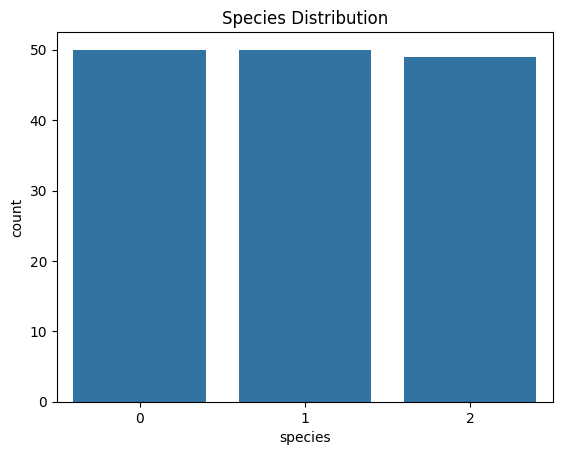

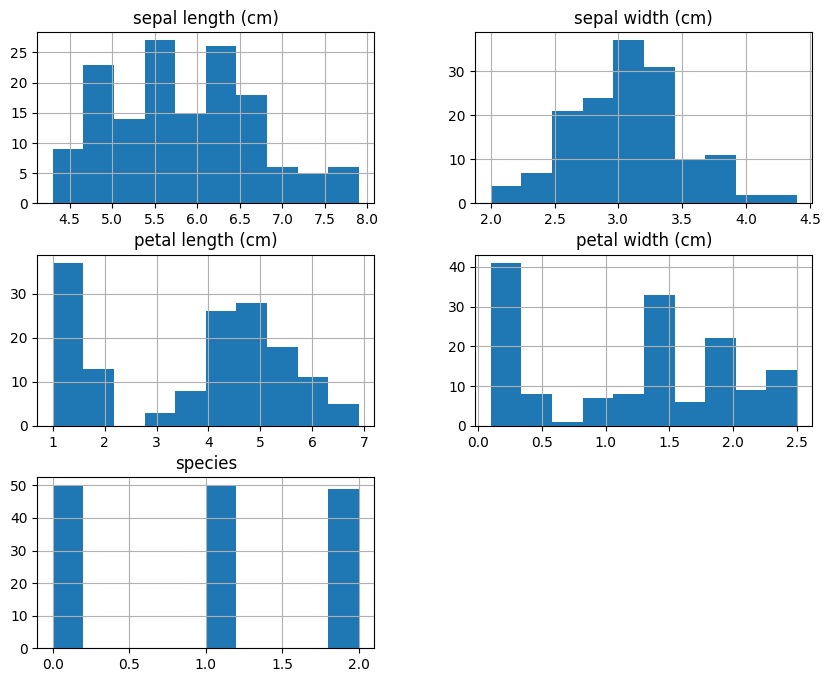

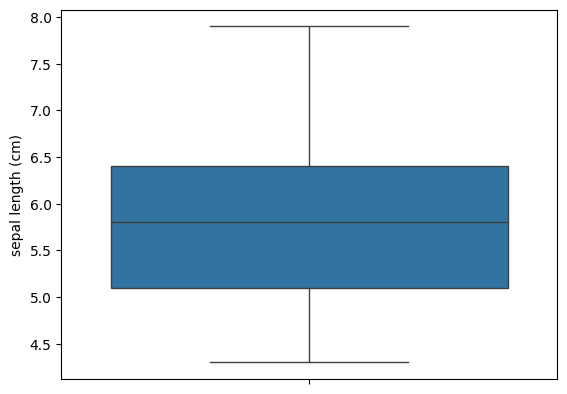

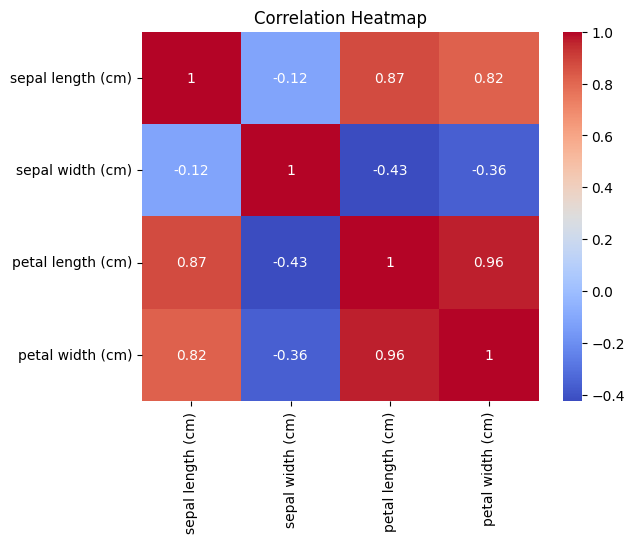

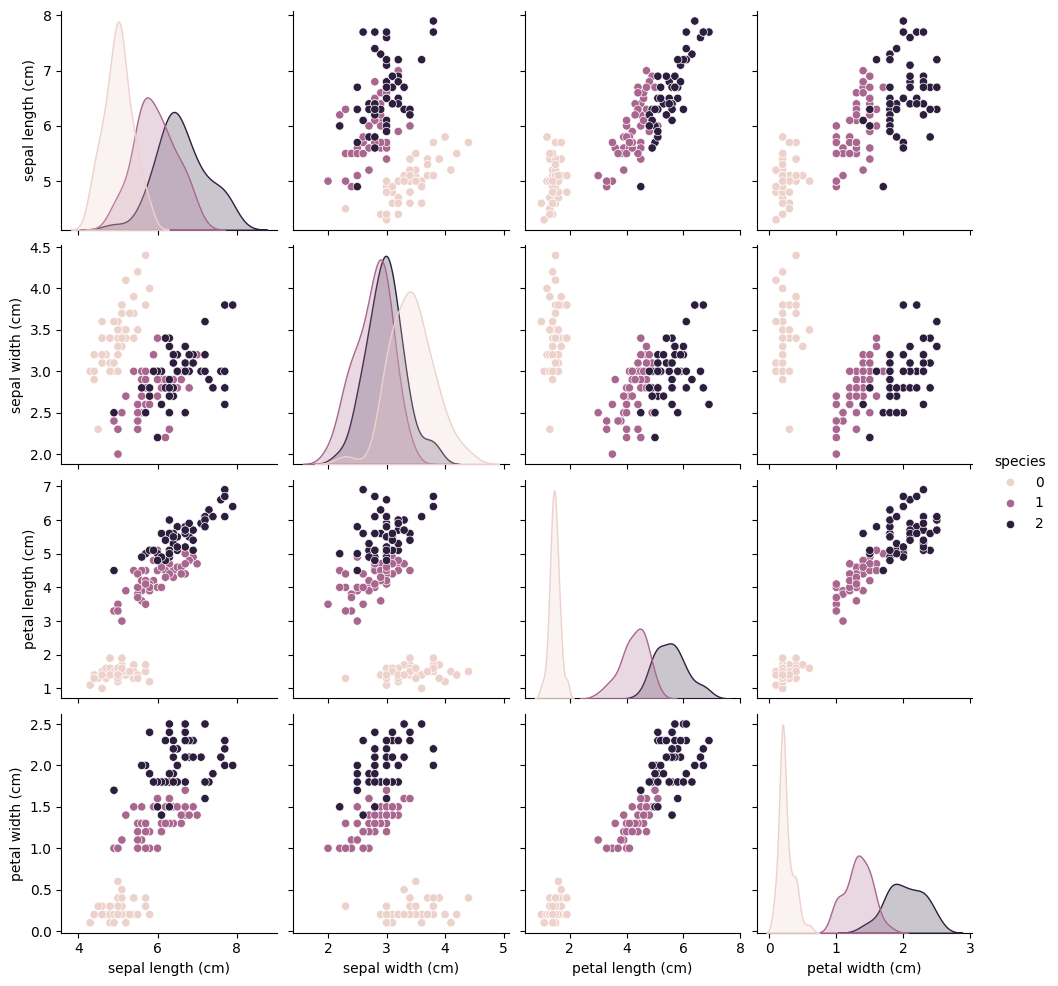

In [5]:
# =========================
# 4. VISUALIZATION
# =========================

sns.countplot(x='species', data=df)
plt.title("Species Distribution")
plt.show()

df.hist(figsize=(10, 8))
plt.show()

sns.boxplot(y=df['sepal length (cm)'])
plt.show()

sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df, hue='species')
plt.show()


In [6]:
# =========================
# 5. SPLIT DATA
# =========================
X = df.iloc[:, 0:4]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [7]:
# =========================
# 6. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# =========================
# 7. MODEL 1 - LOGISTIC REGRESSION
# =========================
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Classification Report:\n", classification_report(y_test, lr_pred))



=== Logistic Regression ===
Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [9]:
# =========================
# 8. MODEL 2 - DECISION TREE
# =========================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Classification Report:\n", classification_report(y_test, dt_pred))



=== Decision Tree ===
Accuracy: 0.9666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [10]:
# =========================
# 9. MODEL 3 - RANDOM FOREST
# =========================
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))


=== Random Forest ===
Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [11]:
# =========================
# 10. CROSS VALIDATION
# =========================
scores = cross_val_score(RandomForestClassifier(), X_train, y_train, cv=5)

print("\nCross Validation Mean Accuracy:", scores.mean())


Cross Validation Mean Accuracy: 0.95


In [12]:
# =========================
# 11. GRID SEARCH (BEST MODEL)
# =========================
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 3, 'n_estimators': 50}


In [13]:
# =========================
# 12. FINAL MODEL
# =========================
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL (TUNED RANDOM FOREST) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


=== FINAL MODEL (TUNED RANDOM FOREST) ===
Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



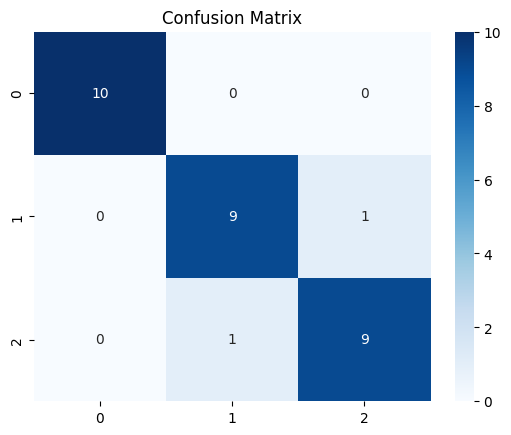

In [14]:
# =========================
# 13. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


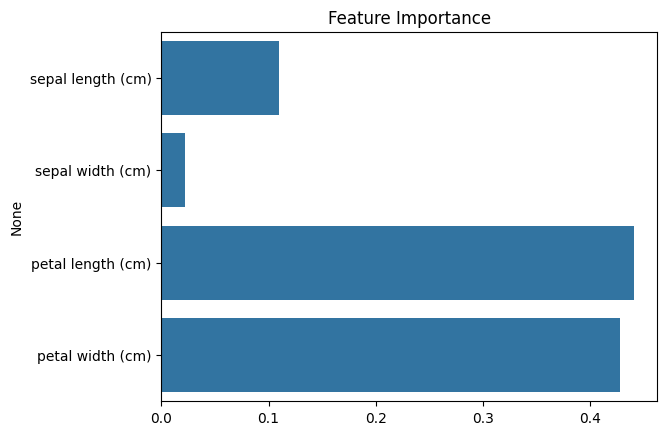

In [15]:
# =========================
# 14. FEATURE IMPORTANCE
# =========================
importance = best_model.feature_importances_
features = X.columns

sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()


In [16]:
# =========================
# 15. NEW DATA PREDICTION
# =========================
new_data = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

new_data = scaler.transform(new_data)

prediction = best_model.predict(new_data)

print(iris.target_names[prediction[0]])

setosa
